### NMF_to_FastMNMF_Audio_Separation



##### Code Explanation
###### -nmf_basic_example() – Demonstrates a basic NMF using synthetic data.
###### -visualize_nmf() – Visualizes the NMF results.
###### -multichannel_nmf() – Applies NMF to each channel of a multichannel audio file.
###### -fastmnmf() – Uses an iterative approach for FastMNMF.
###### -save_reconstructed_audio() – Converts the reconstructed spectrogram back to audio and saves it.


##### Tips on What to Look For
###### -Channel Separation: In the spectrograms
###### -look for differences in spectral content between channels. (You should see distinct patterns in each channel’s spectrogram, reflecting different sources or audio characteristics.)
###### -Reconstruction Quality: Listen to the saved reconstructed audio files to assess if the separation is successful. Ideally, each output should isolate distinct elements of the audio content.

#### Import necessary libraries and testing the wav file

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft
import librosa
import soundfile as sf

audio_path = '/home/ZA/Music/Media project expose files/AMF_MP/new wav files/multichannel.wav'
audio_data, sample_rate = sf.read(audio_path)

print(f"Audio Channels: {audio_data.shape[1] if audio_data.ndim > 1 else 1}")
print(f"Sample Rate: {sample_rate}")
print(f"Audio Shape: {audio_data.shape}")

Audio Channels: 6
Sample Rate: 44100
Audio Shape: (342193, 6)


#### If file is upto standard
###### Set the audio_path in Cell 6 to the path of this file, /path/to/your/multichannel.wav, replacing it with the actual path.

###### Run the Notebook:
###### -Start from Cell 6 and run each cell sequentially.
###### -Observe spectrogram outputs for each channel to see how the audio data varies.
###### -Review the reconstructed outputs to assess if separation between sources is effective.

##### Basic Non-Negative Matrix Factorization (NMF) on Synthetic Data

In [5]:
''''
Starts with Non-Negative Matrix Factorization (NMF) on synthetic data as an introduction. 
It then advances to Multichannel NMF (MNMF), extending to a simplified FastMNMF implementation. 
This setup introduces each step with comments and docstrings, so your partner can follow along and build upon your work.

'''

def nmf_basic_example():
    """
    Performs basic NMF on a synthetic non-negative matrix.
    Demonstrates the concept of NMF on sample data.
    """
    # Generate a sample non-negative matrix V
    np.random.seed(0)
    V = np.random.rand(4, 6)

    # Initialize parameters
    rank = 2  # Rank of the factorization (number of components)
    max_iterations = 1000
    tolerance = 1e-5

    # Initialize W and H with random values
    m, n = V.shape
    W = np.random.rand(m, rank)
    H = np.random.rand(rank, n)

    # Iteratively update W and H to minimize reconstruction error
    for iteration in range(max_iterations):
        H *= (W.T @ V) / (W.T @ W @ H + 1e-10)
        W *= (V @ H.T) / (W @ H @ H.T + 1e-10)

        # Calculate reconstruction error
        reconstruction_error = np.linalg.norm(V - W @ H, 'fro')
        if reconstruction_error < tolerance:
            print(f'Converged in {iteration} iterations')
            break

    print("NMF on synthetic data completed")
    return V, W, H, W @ H, reconstruction_error

#### Visualizing NMF results

In [ ]:
def visualize_nmf(V, W, H, reconstructed):
    """
    Visualizes the original, factorized, and reconstructed matrices from NMF.
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    matrices = [V, W, H, reconstructed]
    titles = ['Original Matrix V', 'Factorized Matrix W', 'Factorized Matrix H', 'Reconstructed (W @ H)']

    for i, (matrix, title) in enumerate(zip(matrices, titles)):
        axes[i].imshow(matrix, aspect='auto', cmap='viridis')
        axes[i].set_title(title)
        axes[i].set_xlabel('Columns')
        axes[i].set_ylabel('Rows')

    plt.tight_layout()
    plt.show()


##### Run NMF on Synthetic Data and Visualize Results

NMF on synthetic data completed


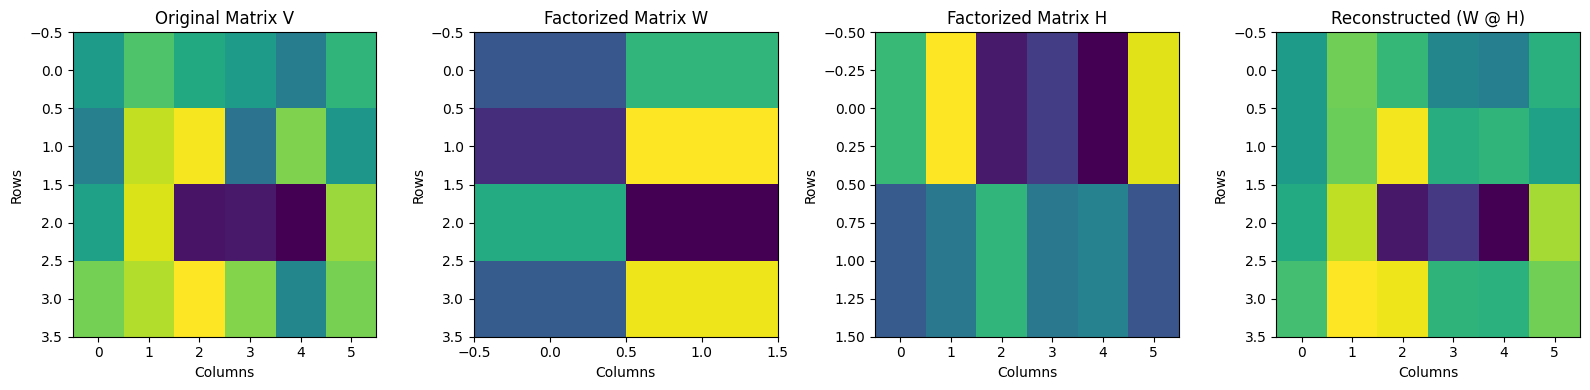

In [6]:
# Run NMF on synthetic data and visualize
V, W, H, reconstructed, error = nmf_basic_example()
visualize_nmf(V, W, H, reconstructed)


#### Multichannel NMF on Audio Data - Core function


In [ ]:
def multichannel_nmf(audio_path, rank=5):
    """
    Applies NMF to a multichannel audio file, separating each channel into components.
    Uses STFT to create spectrograms for each channel.
    
    Parameters:
        audio_path (str): Path to the multichannel audio file
        rank (int): Number of components for NMF
    """
    # Load multichannel audio and use only the first 2 channels
    y, sr = sf.read(audio_path)
    if y.ndim < 2:
        raise ValueError("The provided audio file does not have multiple channels.")
    
    # For initial testing, use only the first 2 channels
    y = y[:, :2]

    num_channels = y.shape[1]
    V = []

    # Compute spectrogram for each channel
    for c in range(num_channels):
        channel_audio = y[:, c]
        spectrogram = np.abs(librosa.stft(channel_audio, n_fft=1024, hop_length=512))**2
        V.append(spectrogram)

    # Initialize W and H for NMF
    m, n = V[0].shape
    W = np.random.rand(m, rank)
    H = np.random.rand(rank, n)

    # Iteratively update W and H to minimize reconstruction error across all channels
    for iteration in range(1000):
        H *= sum(W.T @ V[c] / (W.T @ W @ H + 1e-10) for c in range(num_channels))
        W *= sum(V[c] @ H.T / (W @ H @ H.T + 1e-10) for c in range(num_channels))

    print("Multichannel NMF completed")
    return W, H, V, sr

##### Run Multichannel NMF on Audio Data - Cell 6 (add path here)

In [ ]:
# Apply Multichannel NMF on an audio file
audio_path = '/path/to/multichannel_audio.wav'  # Update with the actual path
W, H, V, sr = multichannel_nmf(audio_path)


##### FastMNMF (Simplified Implementation)

In [ ]:
def fastmnmf(audio_path, rank=5, max_iterations=500):
    """
    Applies FastMNMF to separate audio sources from a multichannel audio file.
    
    Parameters:
        audio_path (str): Path to the multichannel audio file
        rank (int): Number of components for NMF
        max_iterations (int): Maximum number of iterations for convergence
    """
    # Load multichannel audio and use only the first 2 channels
    y, sr = sf.read(audio_path)
    if y.ndim < 2:
        raise ValueError("Audio file must be multichannel.")
    
    # For initial testing, use only the first 2 channels
    y = y[:, :2]

    num_channels = y.shape[1]
    V = []
    
    # Calculate spectrograms for each channel
    for c in range(num_channels):
        channel_audio = y[:, c]
        spectrogram = np.abs(librosa.stft(channel_audio, n_fft=1024, hop_length=512))**2
        V.append(spectrogram)
    
    # Initialize variables
    m, n = V[0].shape
    W = np.random.rand(m, rank)
    H = np.random.rand(rank, n)
    
    # FastMNMF iterative updates
    for iteration in range(max_iterations):
        H *= sum(W.T @ V[c] / (W.T @ W @ H + 1e-10) for c in range(num_channels))
        W *= sum(V[c] @ H.T / (W @ H @ H.T + 1e-10) for c in range(num_channels))
        
    print("FastMNMF completed")
    return W, H, V, sr


#### Run FastMNMF on Audio Data

In [ ]:
# Apply FastMNMF for enhanced separation
W, H, V, sr = fastmnmf(audio_path)

##### Save Reconstructed Audio

In [ ]:
def save_reconstructed_audio(W, H, sr, output_folder="reconstructed"):
    """
    Converts reconstructed spectrograms back to audio and saves them.
    
    Parameters:
        W (np.ndarray): Basis matrix from NMF.
        H (np.ndarray): Activation matrix from NMF.
        sr (int): Sampling rate of the original audio.
        output_folder (str): Folder path to save the reconstructed audio.
    """
    import os
    os.makedirs(output_folder, exist_ok=True)
    
    # Reconstruct the spectrogram and convert it back to audio
    reconstructed_spectrogram = W @ H
    reconstructed_audio = librosa.istft(np.sqrt(reconstructed_spectrogram), hop_length=512)
    
    # Save the reconstructed audio
    output_path = os.path.join(output_folder, "reconstructed.wav")
    sf.write(output_path, reconstructed_audio, sr)
    print(f"Reconstructed audio saved to {output_path}")

##### Save the Reconstructed Audio from FastMNMF

In [ ]:
# Save the reconstructed audio
save_reconstructed_audio(W, H, sr)